<a href="https://colab.research.google.com/github/camparham/Airbnb-Amenities-Feature-Correlation-Analysis/blob/main/Copy_of_Airbnb_Amenities_%26_Feature_Correlation_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Airbnb Amenities & Feature Correlation Analysis**

## Goal: Analyze how features like number of beds, bathrooms, and amenities influence each other using correlation heatmaps, and identify insights that could inform property listing strategies.

## Table of contents


*   Step 1: Library/module importing
*   Step 2: Data collection and preprocessing
*   Step 3: Print and explore the data frame
*   Step 4: Analyze the data frame
*   Conclusatory summary





### **Step 1: Import libraries or modules, which are collections of pre-written code you can use so you don't have to reinvent the wheel.**

In [ ]:
# Import for data manipulation & analysis (DataFrames, Series)
import pandas as pd

# Import for interactive plotting and visualization
import plotly.express as px

# Import for numerical computing and arrays
import numpy as np


# Import seialize/deserialize Python objects
import pickle

# Import statistical data visualization (built on matplotlib)
import seaborn as sns

# Import static plotting and charting
import matplotlib.pyplot as plt

# Convert text to token count vectors
from sklearn.feature_extraction.text import CountVectorizer



In [ ]:
pip install pd

### **Step 2: Data collection and preprocessing**

In [ ]:
# Mount Google Drive so I can pull the data from an uploaded file from my Google Drive, that was originally sourced from Kaggle
from google.colab import drive
drive.mount('/content/drive')



# Replace with the actual path to your file in Google Drive
file_path = "/content/drive/MyDrive/airbnb 2.csv"

# Reads a CSV file from the given path into a Pandas DataFrame called df_airbnb
df = pd.read_csv(file_path)

# Displays the first 5 rows of the DataFrame for a quick preview
df.head()



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Unnamed: 0,id,name,rating,reviews,host_name,host_id,address,features,amenities,...,price,country,bathrooms,beds,guests,toiles,bedrooms,studios,checkin,checkout
0,0,49849504,Perla bungalov,4.71,64,Mehmetcan,357334205.0,"Kartepe, Kocaeli, Turkey","2 guests,2 bedrooms,1 bed,1 bathroom","Mountain view,Valley view,Lake access,Kitchen,...",...,8078,Turkey,1,1,2,0,2,0,Flexible,12 00 pm
1,1,50891766,Authentic Beach Architect Sheltered Villa with...,New,0,Fatih,386223873.0,"Kaş, Antalya, Turkey","4 guests,2 bedrooms,2 beds,2 bathrooms","Kitchen,Wifi,Dedicated workspace,Free parking ...",...,4665,Turkey,2,2,4,0,2,0,4 00 pm - 11 00 pm,10 00 am
2,2,50699164,cottages sataplia,4.85,68,Giorgi,409690853.0,"Imereti, Georgia","4 guests,1 bedroom,3 beds,1 bathroom","Mountain view,Kitchen,Wifi,Dedicated workspace...",...,5991,Georgia,1,3,4,0,1,0,After 1 00 pm,12 00 pm
3,3,49871422,Sapanca Breathable Bungalow,5.0,13,Melih,401873242.0,"Sapanca, Sakarya, Turkey","4 guests,1 bedroom,2 beds,1 bathroom","Mountain view,Valley view,Kitchen,Wifi,Free pa...",...,11339,Turkey,1,2,4,0,1,0,After 2 00 pm,12 00 pm
4,4,51245886,Bungalov Ev 2,New,0,Arp Sapanca,414884116.0,"Sapanca, Sakarya, Turkey","2 guests,1 bedroom,1 bed,1 bathroom","Kitchen,Wifi,Free parking on premises,TV,Air c...",...,6673,Turkey,1,1,2,0,1,0,After 2 00 pm,12 00 pm


In [ ]:
# Showcase the amount of columns (23) are rows (12805)
print(df.shape)

(12805, 23)


In [ ]:
# Showcase the dataframe structure
df.info

<bound method DataFrame.info of        Unnamed: 0        id  \
0               0  49849504   
1               1  50891766   
2               2  50699164   
3               3  49871422   
4               4  51245886   
...           ...       ...   
12800       12800  44697740   
12801       12801  29975283   
12802       12802  32977697   
12803       12803   8006146   
12804       12804  40547903   

                                                    name rating reviews  \
0                                         Perla bungalov   4.71      64   
1      Authentic Beach Architect Sheltered Villa with...    New       0   
2                                      cottages sataplia   4.85      68   
3                            Sapanca Breathable Bungalow    5.0      13   
4                                          Bungalov Ev 2    New       0   
...                                                  ...    ...     ...   
12800            Brown Dome House No. 3, full of healing   4.94      16   
12801       Bubble Hotel Ubud with Bathtub under the Sky   4.67       6   
12802                                   Paradise Eco Hub   4.67       3   
12803     WisDOME - Mentigi Bay Village - Gilis - Lombok   4.86       7   
12804   Enjoy Vitamin SEA!  Ocean Front! [Ocean's Seven]   4.85      13   

         host_name      host_id  \
0        Mehmetcan  357334205.0   
1            Fatih  386223873.0   
2           Giorgi  409690853.0   
3            Melih  401873242.0   
4      Arp Sapanca  414884116.0   
...            ...          ...   
12800        Aidan  161552316.0   
12801       Martha  118954227.0   
12802        Silas  175214568.0   
12803      Cempaka     718423.0   
12804         Achy  246470880.0   

                                                 address  \
0                               Kartepe, Kocaeli, Turkey   
1                                   Kaş, Antalya, Turkey   
2                                       Imereti, Georgia   
3                               Sapanca, Sakarya, Turkey   
4                               Sapanca, Sakarya, Turkey   
...                                                  ...   
12800  Imhoe-myeon, Jindo, South Jeolla Province, Sou...   
12801                                 Gianyar, Indonesia   
12802                                     Kabale, Uganda   
12803        Gunung Sari, Nusa Tenggara Barat, Indonesia   
12804                              Uruma, Okinawa, Japan   

                                           features  \
0              2 guests,2 bedrooms,1 bed,1 bathroom   
1            4 guests,2 bedrooms,2 beds,2 bathrooms   
2              4 guests,1 bedroom,3 beds,1 bathroom   
3              4 guests,1 bedroom,2 beds,1 bathroom   
4               2 guests,1 bedroom,1 bed,1 bathroom   
...                                             ...   
12800                          4 guests,8 bathrooms   
12801     2 guests,1 bedroom,1 bed,Toilet with sink   
12802  2 guests,1 bedroom,2 beds,1 private bathroom   
12803      8 guests,2 bedrooms,4 beds,2.5 bathrooms   
12804          5 guests,1 bedroom,2 beds,1 bathroom   

                                               amenities  ...  price  \
0      Mountain view,Valley view,Lake access,Kitchen,...  ...   8078   
1      Kitchen,Wifi,Dedicated workspace,Free parking ...  ...   4665   
2      Mountain view,Kitchen,Wifi,Dedicated workspace...  ...   5991   
3      Mountain view,Valley view,Kitchen,Wifi,Free pa...  ...  11339   
4      Kitchen,Wifi,Free parking on premises,TV,Air c...  ...   6673   
...                                                  ...  ...    ...   
12800  Kitchen,Wifi,Free parking on premises,Private ...  ...   4288   
12801  Wifi,Free on-street parking,Air conditioning,G...  ...  15200   
12802  Wifi,Breakfast,Long-term stays allowed,Unavail...  ...   9103   
12803  Kitchen,Wifi,Dedicated workspace,Free parking ...  ...  42262   
12804  Sea view,Beach access – Beachfront,Kitchen,Wif...  ...   9909   

            country bathro

### **Step 3: Print and explore the dataframe**

In [ ]:
# Showcase the first 500 rows for skimable review
df =df.head(100)
df

,Unnamed: 0,id,name,rating,reviews,host_name,host_id,address,features,amenities,...,price,country,bathrooms,beds,guests,toiles,bedrooms,studios,checkin,checkout
0,0,49849504,Perla bungalov,4.71,64,Mehmetcan,357334205.0,"Kartepe, Kocaeli, Turkey","2 guests,2 bedrooms,1 bed,1 bathroom","Mountain view,Valley view,Lake access,Kitchen,...",...,8078,Turkey,1,1,2,0,2,0,Flexible,12 00 pm
1,1,50891766,Authentic Beach Architect Sheltered Villa with...,New,0,Fatih,386223873.0,"Kaş, Antalya, Turkey","4 guests,2 bedrooms,2 beds,2 bathrooms","Kitchen,Wifi,Dedicated workspace,Free parking ...",...,4665,Turkey,2,2,4,0,2,0,4 00 pm - 11 00 pm,10 00 am
2,2,50699164,cottages sataplia,4.85,68,Giorgi,409690853.0,"Imereti, Georgia","4 guests,1 bedroom,3 beds,1 bathroom","Mountain view,Kitchen,Wifi,Dedicated workspace...",...,5991,Georgia,1,3,4,0,1,0,After 1 00 pm,12 00 pm
3,3,49871422,Sapanca Breathable Bungalow,5.0,13,Melih,401873242.0,"Sapanca, Sakarya, Turkey","4 guests,1 bedroom,2 beds,1 bathroom","Mountain view,Valley view,Kitchen,Wifi,Free pa...",...,11339,Turkey,1,2,4,0,1,0,After 2 00 pm,12 00 pm
4,4,51245886,Bungalov Ev 2,New,0,Arp Sapanca,414884116.0,"Sapanca, Sakarya, Turkey","2 guests,1 bedroom,1 bed,1 bathroom","Kitchen,Wifi,Free parking on premises,TV,Air c...",...,6673,Turkey,1,1,2,0,1,0,After 2 00 pm,12 00 pm
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,95,50294472,DREAM RIVER EXCLUSIVE BUNGALOW,New,0,Uğur,267547694.0,"Çamlıhemşin, Rize, Turkey","6 guests,2 bedrooms,1 bathroom","Waterfront,Garden,Hair dryer,Refrigerator,Brea...",...,16708,Turkey,1,0,6,0,2,0,After 3 00 pm,12 00 pm
96,96,549090813698523430,A-haus Villa 1\nMin 2pax - Max 6pax,New,2,Isla Del Antoño,407902794.0,"Cavinti, Calabarzon, Philippines","6 guests,1 bedroom,5 beds,1 bathroom","Lake view,Mountain view,Waterfront,Kitchen,Ded...",...,5409,Philippines,1,5,6,0,1,0,After 2 00 pm,12 00 pm
97,97,616944098140295835,Villa Hidden Paradise Garden,New,0,Mert,456865839.0,"Muğla, Turkey","4 guests,2 bedrooms,4 beds,1 bathroom","Garden view,Mountain view,Wifi – 11 Mbps,Dedic...",...,5067,Turkey,1,4,4,0,2,0,After 3 00 pm,NaN
98,98,35530234,Triangle on the rocks!,4.94,16,Socratis,38772874.0,"Amargeti, Paphos, Cyprus","2 guests,1 bed,Shared toilet with sink","Kitchen,Free parking on premises,Pets allowed,...",...,1903,Cyprus,0,1,2,1,0,0,3 00 pm - 7 00 pm,12 00 pm


## **Step 4: Make a recommendation: What's missing from this dataframe that could contribute to growth in different lines of business?**

In [ ]:
# Let's look at the relationship between frequency of guests and the size of the AirBnB


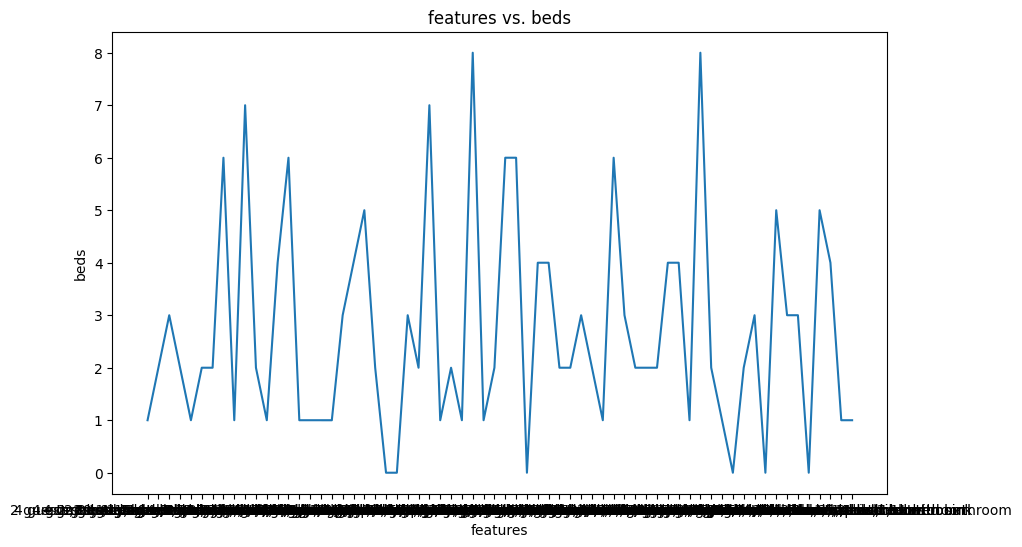

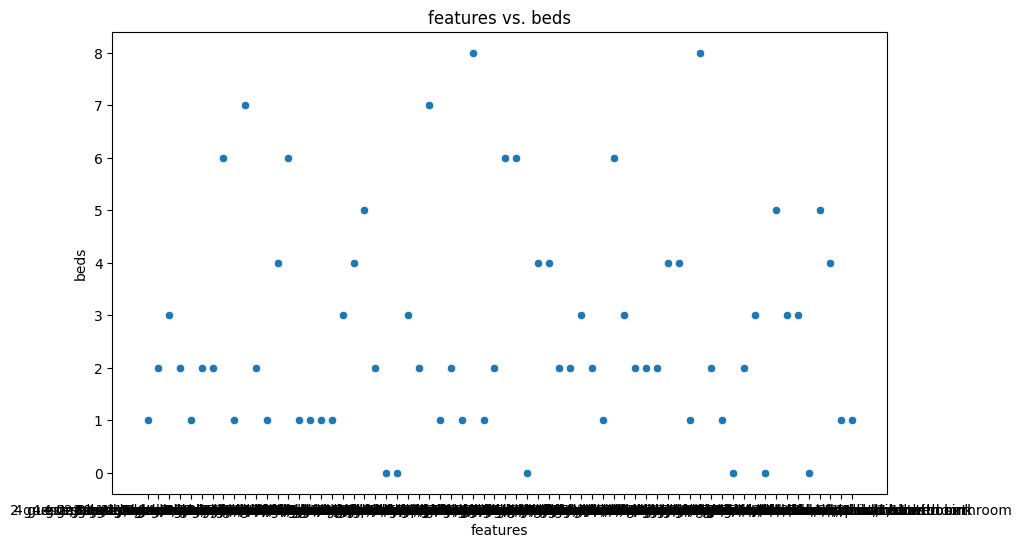

In [ ]:
# Visualize the relationship between number of guests and number of bedrooms
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='features', y='beds')
plt.title('features vs. beds')
plt.xlabel('features')
plt.ylabel('beds')
plt.show()

# Visualize the relationship between number of guests and number of beds
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='features', y='beds')
plt.title('features vs. beds')
plt.xlabel('features')
plt.ylabel('beds')
plt.show()

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df_airbnb["features"], df_airbnb["address"])
plt.xticks(rotation=90)
plt.show()

In [ ]:
pd.set_option('display.max_columns', None)
df_airbnb

### **Step 4: Analyze the data frame**

In [ ]:
df.repeat_hosts = df['name'].value_counts()[df['name'].value_counts() > 1]
df.repeat_hosts



In [ ]:
df_airbnb['host_counts'] = df_airbnb['host_id'].map(df['host_id'].value_counts())

filtered_df = df_airbnb[df_airbnb['host_counts'] > 15]

filtered_df

In [ ]:

host_counts= df['name'].value_counts()
host_counts


In [ ]:
sum_df = filtered_df.iloc[:, [2, 8 ,9, 23]]
sum_df

In [ ]:
has_duplicates = df.duplicated().any()
has_duplicates

In [ ]:
df.isnull().sum()

### **Step 5: Visualize the correlation matrix**

Question: What is the correlation between features and the frequency of guests?





/tmp/ipython-input-914555254.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['num_guests'] = df['features'].str.extract(r'(\d+) guests').astype(float)
/tmp/ipython-input-914555254.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['num_bedrooms'] = df['features'].str.extract(r'(\d+) bedroom').astype(float)
/tmp/ipython-input-914555254.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the c

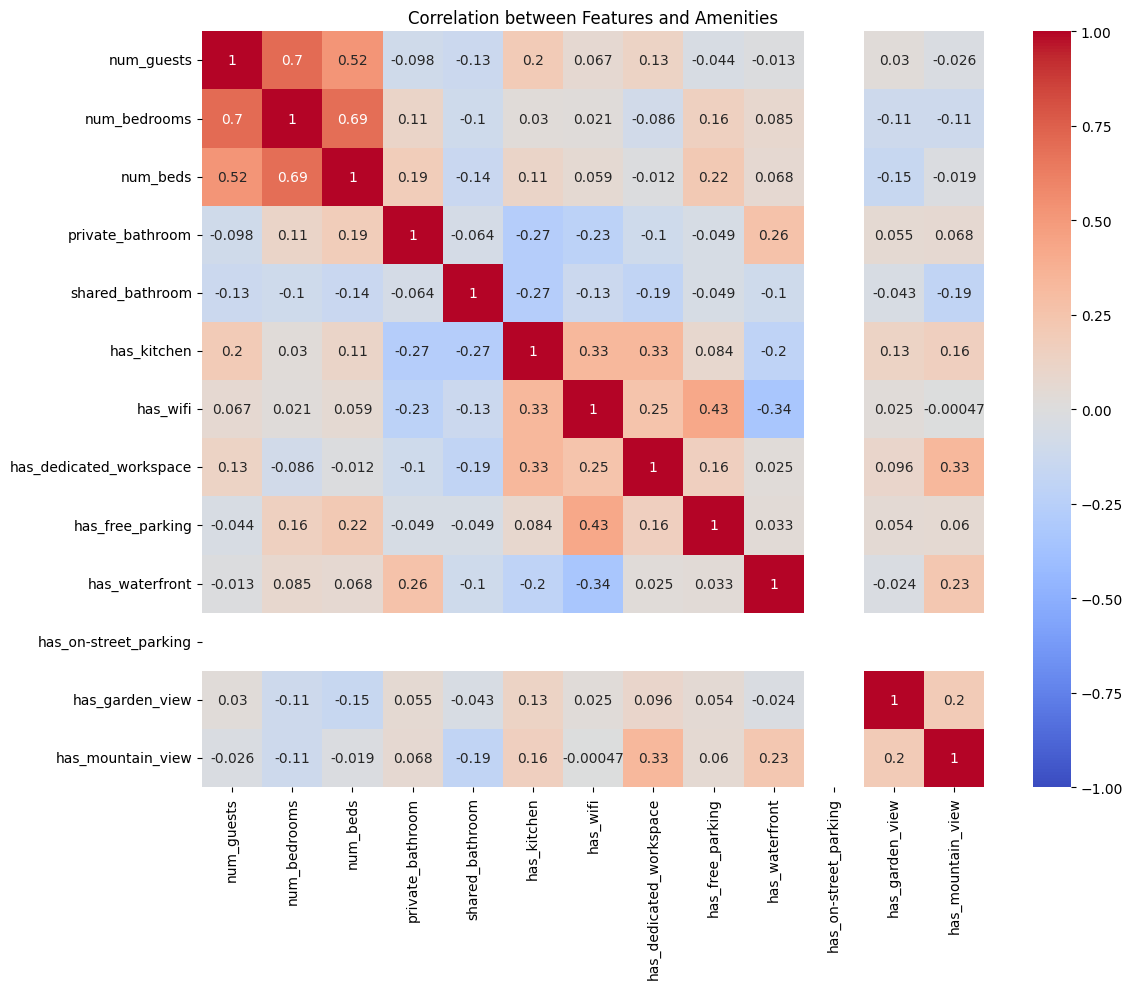

In [ ]:
# Parse the features column into separate attributes
# Extract number of guests, bedrooms, beds, bathroom types
df['num_guests'] = df['features'].str.extract(r'(\d+) guests').astype(float)
df['num_bedrooms'] = df['features'].str.extract(r'(\d+) bedroom').astype(float)
df['num_beds'] = df['features'].str.extract(r'(\d+) beds').astype(float)
df['private_bathroom'] = df['features'].str.contains('private bathroom').astype(int)
df['shared_bathroom'] = df['features'].str.contains('shared bathroom').astype(int)

# Parse amenities into binary columns
amenity_types = ['Kitchen', 'Wifi', 'Dedicated workspace', 'Free parking',
                'Waterfront', 'On-street parking', 'Garden view', 'Mountain view']

for amenity in amenity_types:
    df[f'has_{amenity.lower().replace(" ", "_")}'] = df['amenities'].str.contains(amenity).astype(int)

# Calculate correlation between features and amenities
feature_cols = ['num_guests', 'num_bedrooms', 'num_beds', 'private_bathroom', 'shared_bathroom']
amenity_cols = [f'has_{amenity.lower().replace(" ", "_")}' for amenity in amenity_types]

# Create a correlation matrix
correlation_matrix = df[feature_cols + amenity_cols].corr()

# Save the correlation data using pickle
with open('feature_amenity_correlation.pkl', 'wb') as f:
    pickle.dump(correlation_matrix, f)

# Visualize the correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation between Features and Amenities')
plt.tight_layout()
plt.savefig('feature_amenity_correlation.png')
plt.show()


## **Conclusatory summary**


✅ **Learnings**


* Core features like number of guests, bedrooms, and beds are strongly correlated, indicating that listings scale in tandem across these attributes.

* Amenities like Wi-Fi, kitchen, and dedicated workspace show weak or no correlation with layout-based features, suggesting that they are independent choices made by hosts rather than tied to property size.

* Notably, 19 of the 28 most frequently booked listings accommodate 4 or more guests, indicating that larger listings may attract higher booking volume, especially for group or family travel.

* Weak or zero correlation among amenities (e.g., garden view, on-street parking) implies that location-specific amenities do not scale predictably with property layout.

🔍 **What Could Be Done Next**

* Regression analysis: Predict pricing or booking frequency based on feature and amenity combinations.

* Clustering: Group listings by feature/amenity profiles to identify market segments (e.g., budget-friendly vs. remote work–optimized properties).

* Time-series analysis: Track how amenity preferences or price trends evolve over time across regions.

* Sentiment or review analysis: Explore if feature-rich listings correlate with higher ratings or review sentiment.

🌍 **Real-World Implications**
* Hosts may benefit from adding high-value amenities (like Wi-Fi, workspace) regardless of listing size, since they’re independent levers that improve appeal.

* Listings designed for larger groups could increase booking frequency, making multi-room properties potentially more profitable.

* Investors and property managers can use correlation insights to strategically upgrade properties and tailor offerings to match booking patterns and guest expectations.